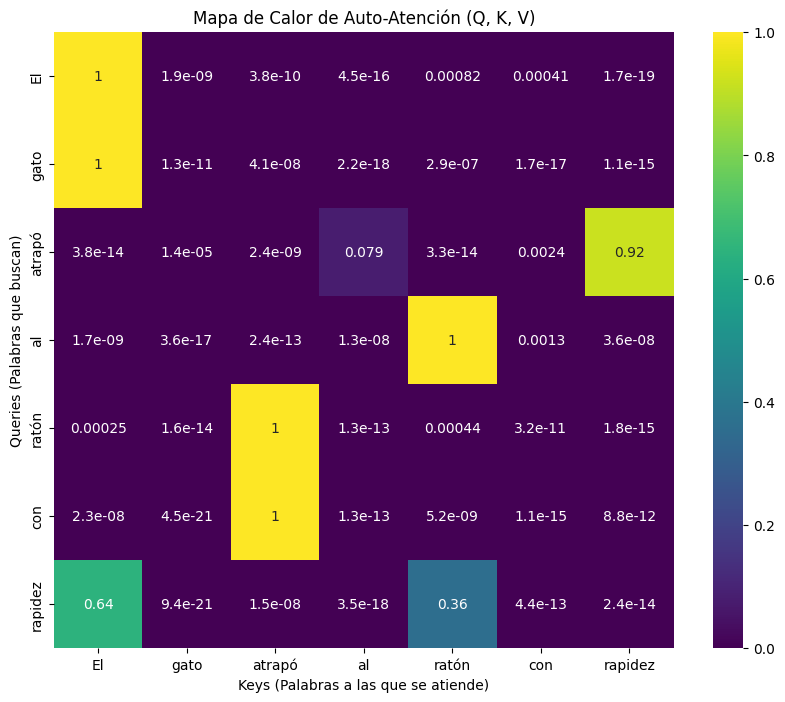

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns

def visualize_attention(sentence):
    words = sentence.split()
    n_words = len(words)

    # 1. Representación ficticia (Embeddings)
    # En un modelo real, estos vendrían de una capa de embedding
    d_model = 16
    embeddings = torch.randn(n_words, d_model)

    # 2. Proyecciones Q, K, V
    # Creamos matrices de pesos aleatorias para simular el aprendizaje
    W_q = torch.randn(d_model, d_model)
    W_k = torch.randn(d_model, d_model)

    Q = torch.matmul(embeddings, W_q)
    K = torch.matmul(embeddings, W_k)

    # 3. Cálculo de Scores (Q * K^T)
    # Multiplicamos cada Query por cada Key
    attention_scores = torch.matmul(Q, K.transpose(0, 1))

    # 4. Escalamiento y Softmax
    d_k = Q.size(-1)
    attention_weights = F.softmax(attention_scores / (d_k ** 0.5), dim=-1)

    # 5. Visualización
    plt.figure(figsize=(10, 8))
    sns.heatmap(attention_weights.detach().numpy(),
                annot=True,
                xticklabels=words,
                yticklabels=words,
                cmap='viridis')

    plt.title("Mapa de Calor de Auto-Atención (Q, K, V)")
    plt.xlabel("Keys (Palabras a las que se atiende)")
    plt.ylabel("Queries (Palabras que buscan)")
    plt.show()

# --- PRUEBA AQUÍ ---
mi_oracion = "El gato atrapó al ratón con rapidez"
visualize_attention(mi_oracion)